# DSA 210 Term Project: The Impact of Travel Distance and Weather Conditions on UEFA Champions League Away Performances

**Student:** Murat Kabaağaç - [00033797]

## Part 1: Importing Libraries and Loading the Data

In this initial step, I import the necessary Python libraries for data manipulation (**pandas**, **numpy**), visualization (**matplotlib**, **seaborn**), and statistical analysis (**scipy**). Then, I upload and load the main match dataset (`games.csv`) that will be used throughout the project.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [ ]:
import pandas as pd

df = pd.read_csv("games.csv")
df.head()

,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
0,1026846,FIWC,2009,Round of 16,2010-06-26,3449,3589,2,1,NaN,...,Nelson Mandela Bay Stadium,30597.0,Wolfgang Stark,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Uruguay,South Korea,2:1,national_team_competition
1,1026847,FIWC,2009,Round of 16,2010-06-27,3437,6303,3,1,NaN,...,FNB-Stadium,84377.0,Roberto Rosetti,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Argentina,Mexico,3:1,national_team_competition
2,1027001,FIWC,2009,Round of 16,2010-06-26,3505,3441,1,2,NaN,...,Royal Bafokeng Stadium,34976.0,Viktor Kassai,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,United States,Ghana,1:2,national_team_competition
3,1027002,FIWC,2009,Round of 16,2010-06-27,3262,3299,4,1,NaN,...,Free State Stadium,40510.0,Jorge Larrionda,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Germany,England,4:1,national_team_competition
4,1027048,FIWC,2009,Round of 16,2010-06-28,3379,3503,2,1,NaN,...,Moses Mabhida Stadion,61962.0,Undiano Mallenco,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Netherlands,Slovakia,2:1,national_team_competition


At this stage, the dataset has been successfully loaded into the notebook. Before moving to the filtering and analysis steps, I first examine its general structure, including the number of rows and columns, as well as the available variable names.

In [ ]:
print("Shape of the dataset:", df.shape)

In [ ]:
print("Column names:")
for col in df.columns:
    print(col)

In [ ]:
df.head()

Part 1 is now complete. The dataset is loaded and its structure is visible. In the next part, I will identify the relevant competition codes and filter the dataset to keep only UEFA Champions League matches.

## Part 2: Filtering UEFA Champions League Matches

Since the original dataset contains matches from multiple competitions, I first identify the available competition codes. Then, I filter the dataset to keep only UEFA Champions League matches. This step is important because the main research question of the project focuses specifically on away-team performance in Champions League games.

In [ ]:
print("Unique competition IDs in the dataset:")
print(df["competition_id"].unique())

Unique competition IDs in the dataset:
['FIWC' 'EURO' 'NLSC' 'SCI' 'BESC' 'USC' 'DFB' 'ELQ' 'L1' 'RU1' 'UKR1'
 'FR1' 'DK1' 'BE1' 'GB1' 'SC1' 'DFL' 'CLQ' 'UKRS' 'UKRP' 'GBCS' 'PO1'
 'NLP' 'ES1' 'TR1' 'SUC' 'FRCH' 'RUSS' 'SFA' 'POCP' 'NL1' 'GR1' 'IT1'
 'POSU' 'CIT' 'CDR' 'DKP' 'CL' 'EL' 'RUP' 'FAC' 'KLUB' 'GRP' 'ECLQ' 'UCOL'
 'AFAC' 'CGB' 'COPA' 'PL1' 'SER1' 'C1' 'TS1' 'A1' 'KR1' 'RO1' 'SA1' 'AUS1'
 'MLS1' 'JAP1' 'NO1' 'SE1' 'MEX1' 'ARG1' 'RSK1' 'BRA1' 'COL1' 'AFCN']


In [ ]:
ucl_df = df[df["competition_id"] == "CL"].copy()

print("Part 2: UEFA Champions League matches filtered successfully!")
print("Shape of the filtered dataset:", ucl_df.shape)
ucl_df.head()

Part 2: UEFA Champions League matches filtered successfully!
Shape of the filtered dataset: (1859, 23)


,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
4483,2262147,CL,2012,Group A,2012-09-18,419,720,0,2,NaN,...,Maksimir,4683.0,Daniele Orsato,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,GNK Dinamo Zagreb,Futebol Clube do Porto,0:2,international_cup
4484,2262148,CL,2012,Group A,2012-09-18,583,338,4,1,NaN,...,Parc des Princes,42536.0,Björn Kuipers,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4:1,international_cup
4485,2262149,CL,2012,Group B,2012-09-18,969,11,1,2,NaN,...,Stade de la Mosson,27522.0,Carlos Velasco Carballo,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Montpellier HSC,Arsenal Football Club,1:2,international_cup
4486,2262150,CL,2012,Group B,2012-09-18,683,33,1,2,NaN,...,Stadio Georgios Karaiskakis,30922.0,David Fernández Borbalán,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1:2,international_cup
4487,2262151,CL,2012,Group C,2012-09-18,1084,964,3,0,NaN,...,La Rosaleda,23670.0,Mark Clattenburg,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Málaga CF,AO FK Zenit Sankt-Peterburg,3:0,international_cup


After filtering the data, I obtain a subset that contains only UEFA Champions League matches. This filtered dataset will be used in the next steps of the project, where I will focus on selecting the relevant variables and preparing the data for analysis.

In [ ]:
print("Number of unique home teams:", ucl_df["home_club_name"].nunique())
print("Number of unique away teams:", ucl_df["away_club_name"].nunique())

Number of unique home teams: 106
Number of unique away teams: 106


## Part 3: Selecting Relevant Variables

After filtering the UEFA Champions League matches, I now focus on the variables that are most relevant to the project. These include the match date, home and away club names, goals scored by each team, and stadium information. Selecting only the necessary variables makes the dataset easier to clean and analyze in the following steps.

In [ ]:
selected_df = ucl_df[[
    "date",
    "home_club_name",
    "away_club_name",
    "home_club_goals",
    "away_club_goals",
    "stadium",
    "attendance"
]].copy()

print("Part 3: Relevant variables selected successfully!")
selected_df.head()

Part 3: Relevant variables selected successfully!


,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance
4483,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0
4484,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0
4485,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0
4486,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0
4487,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0


In [ ]:
print("Shape of the selected dataset:", selected_df.shape)

print("\nSelected columns:")
for col in selected_df.columns:
    print(col)

Shape of the selected dataset: (1859, 7)

Selected columns:
date
home_club_name
away_club_name
home_club_goals
away_club_goals
stadium
attendance


At this stage, I have reduced the filtered dataset to the variables that are directly relevant to the project. In the next step, I will clean the selected data, handle missing values, and prepare the variables for exploratory analysis.

## Part 4: Data Cleaning

Before starting the exploratory analysis, I clean the selected dataset to make it suitable for further analysis. In this step, I convert the date column into a proper datetime format, check for missing values, and remove rows with missing information in the key variables required for the project.

In [ ]:
print("Missing values in each column:")
print(selected_df.isnull().sum())

Missing values in each column:
date                 0
home_club_name       0
away_club_name       0
home_club_goals      0
away_club_goals      0
stadium              3
attendance         126
dtype: int64


In [ ]:
print("Data types before cleaning:")
print(selected_df.dtypes)

Data types before cleaning:
date               datetime64[ns]
home_club_name             object
away_club_name             object
home_club_goals             int64
away_club_goals             int64
stadium                    object
attendance                float64
dtype: object


In [ ]:
selected_df["date"] = pd.to_datetime(selected_df["date"], errors="coerce")

print("Date column converted successfully!")

Date column converted successfully!


In [ ]:
print("Data types after date conversion:")
print(selected_df.dtypes)

Data types after date conversion:
date               datetime64[ns]
home_club_name             object
away_club_name             object
home_club_goals             int64
away_club_goals             int64
stadium                    object
attendance                float64
dtype: object


In [ ]:
clean_df = selected_df.dropna(subset=[
    "date",
    "home_club_name",
    "away_club_name",
    "home_club_goals",
    "away_club_goals",
    "stadium"
]).copy()

print("Part 4: Data cleaned successfully!")
print("Shape before cleaning:", selected_df.shape)
print("Shape after cleaning:", clean_df.shape)

Part 4: Data cleaned successfully!
Shape before cleaning: (1859, 7)
Shape after cleaning: (1856, 7)


In [ ]:
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
date                 0
home_club_name       0
away_club_name       0
home_club_goals      0
away_club_goals      0
stadium              0
attendance         126
dtype: int64


In [ ]:
clean_df.head()

,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance
4483,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0
4484,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0
4485,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0
4486,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0
4487,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0


At this stage, the dataset has been cleaned and prepared for analysis. The date variable is now stored in a proper datetime format, and rows with missing values in the main project variables have been removed. In the next step, I will create new variables to describe away-team performance more clearly.

## Part 5: Feature Engineering

To analyze away-team performance more effectively, I create new variables based on the match result. These variables capture whether the away team won, whether it avoided defeat, and the goal difference from the away team’s perspective. Such variables make the later exploratory analysis and hypothesis testing more interpretable.

In [ ]:
clean_df["away_win"] = (clean_df["away_club_goals"] > clean_df["home_club_goals"]).astype(int)

clean_df["away_not_lose"] = (clean_df["away_club_goals"] >= clean_df["home_club_goals"]).astype(int)

clean_df["away_goal_difference"] = clean_df["away_club_goals"] - clean_df["home_club_goals"]

print("Part 5: New away-performance variables created successfully!")
clean_df.head()

Part 5: New away-performance variables created successfully!


,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance,away_win,away_not_lose,away_goal_difference
4483,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0,1,1,2
4484,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0,0,0,-3
4485,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0,1,1,1
4486,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0,1,1,1
4487,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0,0,0,-3


In [ ]:
print("Away win distribution:")
print(clean_df["away_win"].value_counts())

print("\nAway not lose distribution:")
print(clean_df["away_not_lose"].value_counts())

print("\nSummary of away goal difference:")
print(clean_df["away_goal_difference"].describe())

Away win distribution:
away_win
0    1255
1     601
Name: count, dtype: int64

Away not lose distribution:
away_not_lose
1    969
0    887
Name: count, dtype: int64

Summary of away goal difference:
count    1856.000000
mean       -0.387931
std         2.171947
min        -8.000000
25%        -2.000000
50%         0.000000
75%         1.000000
max         7.000000
Name: away_goal_difference, dtype: float64


In [ ]:
clean_df[[
    "date",
    "home_club_name",
    "away_club_name",
    "home_club_goals",
    "away_club_goals",
    "away_win",
    "away_not_lose",
    "away_goal_difference"
]].head()

,date,home_club_name,away_club_name,home_club_goals,away_club_goals,away_win,away_not_lose,away_goal_difference
4483,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,1,1,2
4484,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,0,0,-3
4485,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,1,1,1
4486,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,1,1,1
4487,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,0,0,-3


At this stage, the dataset includes new variables that directly describe away-team performance. These engineered variables will be useful in the next stage, where I will explore the overall structure of the data through summary statistics and visualizations.

## Part 6: Exploratory Data Analysis

At this stage, I explore the cleaned dataset to better understand the general patterns in UEFA Champions League away performances. I examine summary statistics and use simple visualizations to observe the distribution of away wins, away teams avoiding defeat, and away goal differences.

In [ ]:
clean_df[[
    "home_club_goals",
    "away_club_goals",
    "away_win",
    "away_not_lose",
    "away_goal_difference"
]].describe()

,home_club_goals,away_club_goals,away_win,away_not_lose,away_goal_difference
count,1856.000000,1856.000000,1856.000000,1856.000000,1856.000000
mean,1.741918,1.353987,0.323815,0.522091,-0.387931
std,1.488750,1.341526,0.468056,0.499646,2.171947
min,0.000000,0.000000,0.000000,0.000000,-8.000000
25%,1.000000,0.000000,0.000000,0.000000,-2.000000
50%,1.000000,1.000000,0.000000,1.000000,0.000000
75%,3.000000,2.000000,1.000000,1.000000,1.000000
max,9.000000,8.000000,1.000000,1.000000,7.000000


In [ ]:
away_win_rate = clean_df["away_win"].mean() * 100
away_not_lose_rate = clean_df["away_not_lose"].mean() * 100

print(f"Away win rate: {away_win_rate:.2f}%")
print(f"Away not lose rate: {away_not_lose_rate:.2f}%")

Away win rate: 32.38%
Away not lose rate: 52.21%


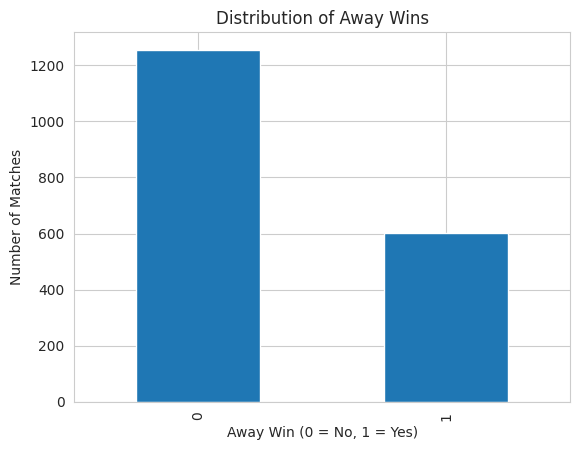

In [ ]:
clean_df["away_win"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Away Wins")
plt.xlabel("Away Win (0 = No, 1 = Yes)")
plt.ylabel("Number of Matches")
plt.show()

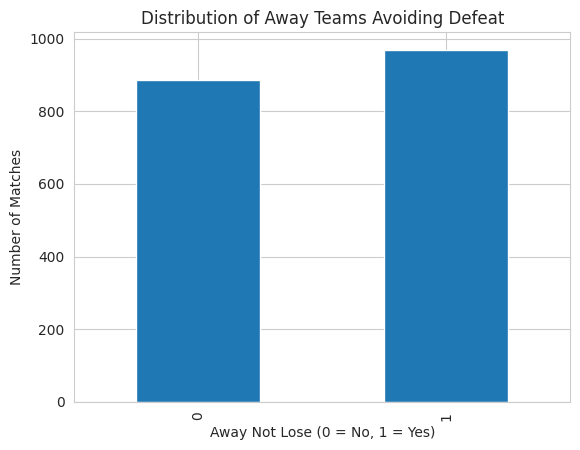

In [ ]:
clean_df["away_not_lose"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Away Teams Avoiding Defeat")
plt.xlabel("Away Not Lose (0 = No, 1 = Yes)")
plt.ylabel("Number of Matches")
plt.show()

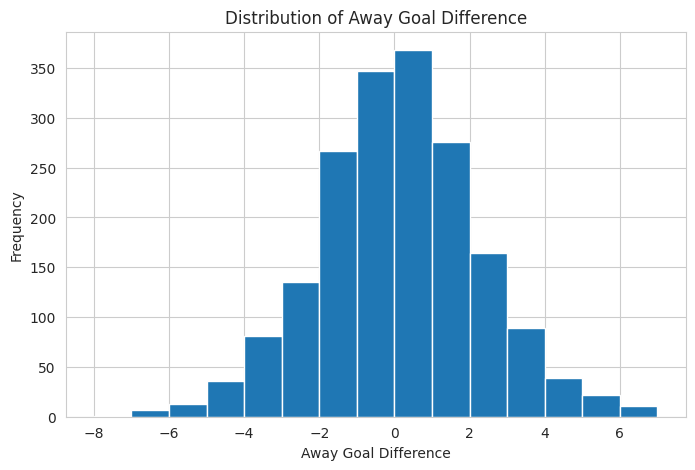

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(clean_df["away_goal_difference"], bins=15)
plt.title("Distribution of Away Goal Difference")
plt.xlabel("Away Goal Difference")
plt.ylabel("Frequency")
plt.show()

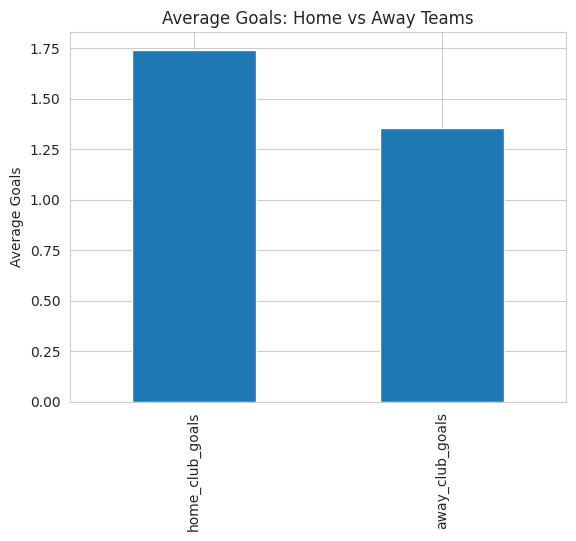

In [ ]:
goal_means = clean_df[["home_club_goals", "away_club_goals"]].mean()

goal_means.plot(kind="bar")
plt.title("Average Goals: Home vs Away Teams")
plt.ylabel("Average Goals")
plt.show()

In [ ]:
print("Average home goals:", clean_df["home_club_goals"].mean())
print("Average away goals:", clean_df["away_club_goals"].mean())

Average home goals: 1.7419181034482758
Average away goals: 1.3539870689655173


The exploratory analysis shows the general structure of away-team performance in UEFA Champions League matches. In particular, the away win rate, away non-loss rate, and the distribution of away goal difference provide a first overview of how away teams perform before introducing distance and weather-related enrichment variables. In the next step, I will apply hypothesis testing to examine whether these observed patterns are statistically meaningful.

## Part 7: Preparing for Enrichment

Before adding external enrichment variables such as travel distance and weather conditions, I first inspect the club and stadium information in the dataset. This step helps me identify the unique teams and stadiums that will later need to be matched with geographic coordinates.

In [ ]:
print("Number of unique home clubs:", clean_df["home_club_name"].nunique())
print("Number of unique away clubs:", clean_df["away_club_name"].nunique())
print("Number of unique stadiums:", clean_df["stadium"].nunique())

Number of unique home clubs: 106
Number of unique away clubs: 106
Number of unique stadiums: 130


In [ ]:
print("Sample home clubs:")
print(clean_df["home_club_name"].dropna().unique()[:20])

Sample home clubs:
['GNK Dinamo Zagreb' 'Paris Saint-Germain Football Club' 'Montpellier HSC'
 'Olympiakos Syndesmos Filathlon Peiraios' 'Málaga CF'
 'Associazione Calcio Milan' 'Real Madrid Club de Fútbol'
 'Borussia Dortmund' 'Chelsea Football Club' 'FC Shakhtar Donetsk'
 'FC Bayern München' 'Lille Olympique Sporting Club'
 'The Celtic Football Club' 'Futbol Club Barcelona'
 'Manchester United Football Club' 'Sporting Clube de Braga'
 'Fodbold Club Nordsjælland' 'Juventus Football Club' 'BATE Borisov'
 'Valencia Club de Fútbol S. A. D.']


In [ ]:
print("Sample away clubs:")
print(clean_df["away_club_name"].dropna().unique()[:20])

Sample away clubs:
['Futebol Clube do Porto' 'Futbolniy Klub Dynamo Kyiv'
 'Arsenal Football Club' 'FC Schalke 04' 'AO FK Zenit Sankt-Peterburg'
 'Royal Sporting Club Anderlecht' 'Manchester City Football Club'
 'AFC Ajax Amsterdam' 'Juventus Football Club' 'Fodbold Club Nordsjælland'
 'Valencia Club de Fútbol S. A. D.' 'BATE Borisov'
 'Sport Lisboa e Benfica' 'FK Spartak Moskva' 'Galatasaray Spor Kulübü'
 'Fotbal Club CFR 1907 Cluj SA' 'Chelsea Football Club'
 'FC Shakhtar Donetsk' 'FC Bayern München' 'Lille Olympique Sporting Club']


In [ ]:
print("Sample stadiums:")
print(clean_df["stadium"].dropna().unique()[:20])

Sample stadiums:
['Maksimir' 'Parc des Princes' 'Stade de la Mosson'
 'Stadio Georgios Karaiskakis' 'La Rosaleda' 'Giuseppe Meazza'
 'Santiago Bernabéu' 'SIGNAL IDUNA PARK' 'Stamford Bridge' 'Donbass Arena'
 'Allianz Arena' 'Decathlon Arena-Stade Pierre-Mauroy' 'Celtic Park'
 'Spotify Camp Nou' 'Old Trafford' 'Estádio Municipal de Braga' 'Parken'
 'Allianz Stadium' 'Dinamo' 'Mestalla']


In [ ]:
stadium_df = clean_df[["home_club_name", "stadium"]].drop_duplicates().reset_index(drop=True)

print("Unique home club - stadium pairs:")
print(stadium_df.shape)
stadium_df.head(20)

Unique home club - stadium pairs:
(161, 2)


,home_club_name,stadium
0,GNK Dinamo Zagreb,Maksimir
1,Paris Saint-Germain Football Club,Parc des Princes
2,Montpellier HSC,Stade de la Mosson
3,Olympiakos Syndesmos Filathlon Peiraios,Stadio Georgios Karaiskakis
4,Málaga CF,La Rosaleda
5,Associazione Calcio Milan,Giuseppe Meazza
6,Real Madrid Club de Fútbol,Santiago Bernabéu
7,Borussia Dortmund,SIGNAL IDUNA PARK
8,Chelsea Football Club,Stamford Bridge
9,FC Shakhtar Donetsk,Donbass Arena


At this stage, I have identified the main clubs and stadiums that appear in the UEFA Champions League dataset. In the next step, I will use this information to build a location mapping table that can later be used for travel-distance calculations and weather-data enrichment.

## Part 8: Creating the Club-Location Reference Table

To calculate travel distance later in the project, I need a reference table that maps each club to its home stadium, city, and country. Instead of building this mapping for only a small subset of teams, I first extract all unique club names appearing in the dataset. This creates a complete reference structure that can later be enriched with location information.

In [ ]:
all_clubs = pd.concat([
    clean_df["home_club_name"],
    clean_df["away_club_name"]
]).dropna().unique()

club_reference_df = pd.DataFrame({
    "club_name": sorted(all_clubs)
})

print("Part 8: Club reference table created successfully!")
print("Number of unique clubs:", club_reference_df.shape[0])
club_reference_df.head(20)

Part 8: Club reference table created successfully!
Number of unique clubs: 106


,club_name
0,1. Fußballclub Union Berlin
1,"AC Sparta Praha, a. s."
2,AFC Ajax Amsterdam
3,AO FK Zenit Sankt-Peterburg
4,APOEL Nicosia
5,Arsenal Football Club
6,Association sportive de Monaco Football Club
7,Associazione Calcio Milan
8,Associazione Sportiva Roma
9,Aston Villa Football Club


In [ ]:
club_reference_df["home_stadium"] = np.nan
club_reference_df["city"] = np.nan
club_reference_df["country"] = np.nan

club_reference_df.head(20)

,club_name,home_stadium,city,country
0,1. Fußballclub Union Berlin,NaN,NaN,NaN
1,"AC Sparta Praha, a. s.",NaN,NaN,NaN
2,AFC Ajax Amsterdam,NaN,NaN,NaN
3,AO FK Zenit Sankt-Peterburg,NaN,NaN,NaN
4,APOEL Nicosia,NaN,NaN,NaN
5,Arsenal Football Club,NaN,NaN,NaN
6,Association sportive de Monaco Football Club,NaN,NaN,NaN
7,Associazione Calcio Milan,NaN,NaN,NaN
8,Associazione Sportiva Roma,NaN,NaN,NaN
9,Aston Villa Football Club,NaN,NaN,NaN


In [ ]:
club_reference_df.to_excel("club_reference_table.xlsx", index=False)
print("Excel file saved successfully!")

Excel file saved successfully!


In [ ]:
from google.colab import files
files.download("club_reference_table.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

At this stage, I have created a complete reference table containing all unique clubs in the dataset. This table will be filled with home stadium, city, and country information, and it will later be used for coordinate matching and travel-distance calculations.

## Part 9: Creating a Stadium Reference Table

Since the project focuses on travel distance and match location, stadium information is especially important. In this step, I create a unique stadium reference table from the UEFA Champions League dataset. This table will later be enriched with city, country, latitude, and longitude information for distance calculations.

In [47]:
stadium_reference_df = pd.DataFrame({
    "stadium_name": sorted(clean_df["stadium"].dropna().unique())
})

stadium_reference_df["city"] = np.nan
stadium_reference_df["country"] = np.nan
stadium_reference_df["latitude"] = np.nan
stadium_reference_df["longitude"] = np.nan

print("Part 9: Stadium reference table created successfully!")
print("Number of unique stadiums:", stadium_reference_df.shape[0])
stadium_reference_df.head(20)

Part 9: Stadium reference table created successfully!
Number of unique stadiums: 130


,stadium_name,city,country,latitude,longitude
0,Ali Sami Yen Spor Kompleksi RAMS Park,NaN,NaN,NaN,NaN
1,Allianz Arena,NaN,NaN,NaN,NaN
2,Allianz Stadium,NaN,NaN,NaN,NaN
3,Almaty Ortalyk Stadion,NaN,NaN,NaN,NaN
4,Anfield,NaN,NaN,NaN,NaN
5,Anoeta,NaN,NaN,NaN,NaN
6,Arena Khimki,NaN,NaN,NaN,NaN
7,Arena Lviv,NaN,NaN,NaN,NaN
8,Arena Națională,NaN,NaN,NaN,NaN
9,Aspmyra Stadion,NaN,NaN,NaN,NaN


In [48]:
stadium_reference_df.to_excel("stadium_reference_table.xlsx", index=False)

print("Excel file saved successfully!")

Excel file saved successfully!


In [49]:
from google.colab import files
files.download("stadium_reference_table.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

At this stage, I have created a structured stadium reference table. This table includes all unique stadiums appearing in the dataset and provides a clean basis for adding location and coordinate information in the next stages of the project. Before the next step I have collected all coordinates for all stadiums. The coordinates couldnt be found by geopy it was causing error in my data so the coordinates were found by AI instead.

## Part 10: Merging the Filled Stadium Reference Table with the Main Dataset

After creating and completing the stadium reference table, the next step is to merge it with the cleaned UEFA Champions League dataset. This allows each match record to include stadium-based location information such as city, country, latitude, and longitude. These variables will later be used for weather-data enrichment and further analysis.

In [55]:
from google.colab import files
uploaded = files.upload()

Saving stadium_reference_table_filled.xlsx to stadium_reference_table_filled.xlsx


In [56]:
stadium_reference_filled = pd.read_excel("stadium_reference_table_filled.xlsx")

print("Part 10: Filled stadium reference table loaded successfully!")
stadium_reference_filled.head()

Part 10: Filled stadium reference table loaded successfully!


,stadium_name,city,country,latitude,longitude
0,Ali Sami Yen Spor Kompleksi RAMS Park,Istanbul,Turkey,41.0765,28.9834
1,Allianz Arena,Munich,Germany,48.2188,11.6247
2,Allianz Stadium,Turin,Italy,45.1096,7.6412
3,Almaty Ortalyk Stadion,Almaty,Kazakhstan,43.2220,76.8512
4,Anfield,Liverpool,England,53.4308,-2.9608


In [57]:
print("Columns in the filled stadium reference table:")
for col in stadium_reference_filled.columns:
    print(col)

Columns in the filled stadium reference table:
stadium_name
city
country
latitude
longitude


In [58]:
enriched_df = clean_df.merge(
    stadium_reference_filled,
    left_on="stadium",
    right_on="stadium_name",
    how="left"
)

print("Main dataset merged with stadium reference table successfully!")
print("Shape of enriched dataset:", enriched_df.shape)
enriched_df.head()

Main dataset merged with stadium reference table successfully!
Shape of enriched dataset: (1856, 15)


,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance,away_win,away_not_lose,away_goal_difference,stadium_name,city,country,latitude,longitude
0,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0,1,1,2,Maksimir,Zagreb,Croatia,45.8177,16.0122
1,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0,0,0,-3,Parc des Princes,Paris,France,48.8414,2.2530
2,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0,1,1,1,Stade de la Mosson,Montpellier,France,43.6200,3.8120
3,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0,1,1,1,Stadio Georgios Karaiskakis,Piraeus,Greece,37.9368,23.6689
4,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0,0,0,-3,La Rosaleda,Málaga,Spain,36.7175,-4.4369


In [59]:
print("Missing city values after merge:", enriched_df["city"].isnull().sum())
print("Missing country values after merge:", enriched_df["country"].isnull().sum())
print("Missing latitude values after merge:", enriched_df["latitude"].isnull().sum())
print("Missing longitude values after merge:", enriched_df["longitude"].isnull().sum())

Missing city values after merge: 0
Missing country values after merge: 0
Missing latitude values after merge: 0
Missing longitude values after merge: 0


In [60]:
enriched_df[[
    "date",
    "home_club_name",
    "away_club_name",
    "stadium",
    "city",
    "country",
    "latitude",
    "longitude"
]].head()

,date,home_club_name,away_club_name,stadium,city,country,latitude,longitude
0,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,Maksimir,Zagreb,Croatia,45.8177,16.0122
1,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,Parc des Princes,Paris,France,48.8414,2.2530
2,2012-09-18,Montpellier HSC,Arsenal Football Club,Stade de la Mosson,Montpellier,France,43.6200,3.8120
3,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,Stadio Georgios Karaiskakis,Piraeus,Greece,37.9368,23.6689
4,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,La Rosaleda,Málaga,Spain,36.7175,-4.4369


At this stage, the UEFA Champions League dataset has been successfully enriched with stadium-based geographic information. Each match now includes the city, country, latitude, and longitude of the match venue. In the next step, I will use this geographic information together with match dates to retrieve weather variables for each match location.

## Part 11: Retrieving Match-Day Weather Data

In this step, I enrich the location-enhanced UEFA Champions League dataset with historical weather information. Using the match date together with the stadium latitude and longitude, I retrieve weather variables for the match location from the Open-Meteo historical weather API. These variables will later be used to examine whether environmental conditions are associated with away-team performance.

In [61]:
import requests
import pandas as pd
import numpy as np

In [62]:
weather_input_df = enriched_df[["date", "stadium", "latitude", "longitude"]].drop_duplicates().copy()

print("Number of unique match-location-date combinations:", weather_input_df.shape[0])
weather_input_df.head()

Number of unique match-location-date combinations: 1856


,date,stadium,latitude,longitude
0,2012-09-18,Maksimir,45.8177,16.0122
1,2012-09-18,Parc des Princes,48.8414,2.2530
2,2012-09-18,Stade de la Mosson,43.6200,3.8120
3,2012-09-18,Stadio Georgios Karaiskakis,37.9368,23.6689
4,2012-09-18,La Rosaleda,36.7175,-4.4369


In [63]:
def get_weather_data(lat, lon, date):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": str(date.date()),
        "end_date": str(date.date()),
        "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
        "timezone": "auto"
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        data = response.json()

        if "daily" in data:
            daily = data["daily"]
            return pd.Series([
                daily.get("temperature_2m_mean", [np.nan])[0],
                daily.get("precipitation_sum", [np.nan])[0],
                daily.get("windspeed_10m_max", [np.nan])[0]
            ])
        else:
            return pd.Series([np.nan, np.nan, np.nan])

    except Exception:
        return pd.Series([np.nan, np.nan, np.nan])

Before applying the weather retrieval process to the full dataset, I first test the API call on a small sample of match-location-date combinations to verify that the enrichment pipeline is working properly.

In [64]:
weather_test_df = weather_input_df.head(5).copy()

weather_test_df[[
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max"
]] = weather_test_df.apply(
    lambda row: get_weather_data(row["latitude"], row["longitude"], row["date"]),
    axis=1
)

print("Weather API test completed!")
weather_test_df

Weather API test completed!


,date,stadium,latitude,longitude,temperature_2m_mean,precipitation_sum,windspeed_10m_max
0,2012-09-18,Maksimir,45.8177,16.0122,19.3,0.1,6.8
1,2012-09-18,Parc des Princes,48.8414,2.2530,15.8,0.0,16.2
2,2012-09-18,Stade de la Mosson,43.6200,3.8120,19.7,0.3,15.9
3,2012-09-18,Stadio Georgios Karaiskakis,37.9368,23.6689,22.8,0.0,9.7
4,2012-09-18,La Rosaleda,36.7175,-4.4369,25.9,0.0,6.5


After confirming that the weather API works on a small sample, I now apply the same enrichment process to the full set of unique match-location-date combinations.

In [65]:
weather_input_df[[
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max"
]] = weather_input_df.apply(
    lambda row: get_weather_data(row["latitude"], row["longitude"], row["date"]),
    axis=1
)

print("Full weather enrichment completed!")
weather_input_df.head()

Full weather enrichment completed!


,date,stadium,latitude,longitude,temperature_2m_mean,precipitation_sum,windspeed_10m_max
0,2012-09-18,Maksimir,45.8177,16.0122,19.3,0.1,6.8
1,2012-09-18,Parc des Princes,48.8414,2.2530,15.8,0.0,16.2
2,2012-09-18,Stade de la Mosson,43.6200,3.8120,19.7,0.3,15.9
3,2012-09-18,Stadio Georgios Karaiskakis,37.9368,23.6689,22.8,0.0,9.7
4,2012-09-18,La Rosaleda,36.7175,-4.4369,25.9,0.0,6.5


In [66]:
print("Missing temperature values:", weather_input_df["temperature_2m_mean"].isnull().sum())
print("Missing precipitation values:", weather_input_df["precipitation_sum"].isnull().sum())
print("Missing windspeed values:", weather_input_df["windspeed_10m_max"].isnull().sum())

Missing temperature values: 6
Missing precipitation values: 6
Missing windspeed values: 6


In [67]:
weather_input_df.to_excel("match_weather_data.xlsx", index=False)
print("Weather dataset saved successfully!")

Weather dataset saved successfully!


In [68]:
from google.colab import files
files.download("match_weather_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
weather_clean_df = weather_input_df.dropna(subset=[
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max"
]).copy()

print("Shape before weather cleaning:", weather_input_df.shape)
print("Shape after weather cleaning:", weather_clean_df.shape)

Shape before weather cleaning: (1856, 7)
Shape after weather cleaning: (1850, 7)


At this stage, I have retrieved historical weather variables for UEFA Champions League match locations and dates. The resulting weather dataset includes temperature, precipitation, and wind-related measures, which can now be merged with the main match-level dataset for the final analysis.

## Part 12: Merging Weather Data with the Main Dataset

After retrieving the historical weather variables for each match location and date, I now merge these weather records back into the main UEFA Champions League dataset. This creates the final enriched match-level dataset, which includes performance variables, stadium-based geographic information, and match-day weather conditions.

In [70]:
final_df = enriched_df.merge(
    weather_clean_df,
    on=["date", "stadium", "latitude", "longitude"],
    how="left"
)

print("Part 12: Weather data merged successfully!")
print("Shape of final enriched dataset:", final_df.shape)
final_df.head()

Part 12: Weather data merged successfully!
Shape of final enriched dataset: (1856, 18)


,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance,away_win,away_not_lose,away_goal_difference,stadium_name,city,country,latitude,longitude,temperature_2m_mean,precipitation_sum,windspeed_10m_max
0,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0,1,1,2,Maksimir,Zagreb,Croatia,45.8177,16.0122,19.3,0.1,6.8
1,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0,0,0,-3,Parc des Princes,Paris,France,48.8414,2.2530,15.8,0.0,16.2
2,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0,1,1,1,Stade de la Mosson,Montpellier,France,43.6200,3.8120,19.7,0.3,15.9
3,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0,1,1,1,Stadio Georgios Karaiskakis,Piraeus,Greece,37.9368,23.6689,22.8,0.0,9.7
4,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0,0,0,-3,La Rosaleda,Málaga,Spain,36.7175,-4.4369,25.9,0.0,6.5


In [71]:
print("Missing temperature values after merge:", final_df["temperature_2m_mean"].isnull().sum())
print("Missing precipitation values after merge:", final_df["precipitation_sum"].isnull().sum())
print("Missing windspeed values after merge:", final_df["windspeed_10m_max"].isnull().sum())

Missing temperature values after merge: 6
Missing precipitation values after merge: 6
Missing windspeed values after merge: 6


In [72]:
final_df[[
    "date",
    "home_club_name",
    "away_club_name",
    "stadium",
    "city",
    "country",
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max",
    "away_win",
    "away_not_lose",
    "away_goal_difference"
]].head()

,date,home_club_name,away_club_name,stadium,city,country,temperature_2m_mean,precipitation_sum,windspeed_10m_max,away_win,away_not_lose,away_goal_difference
0,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,Maksimir,Zagreb,Croatia,19.3,0.1,6.8,1,1,2
1,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,Parc des Princes,Paris,France,15.8,0.0,16.2,0,0,-3
2,2012-09-18,Montpellier HSC,Arsenal Football Club,Stade de la Mosson,Montpellier,France,19.7,0.3,15.9,1,1,1
3,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,Stadio Georgios Karaiskakis,Piraeus,Greece,22.8,0.0,9.7,1,1,1
4,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,La Rosaleda,Málaga,Spain,25.9,0.0,6.5,0,0,-3


In [73]:
final_df.to_excel("final_enriched_dataset.xlsx", index=False)
print("Final enriched dataset saved successfully!")

Final enriched dataset saved successfully!


In [74]:
from google.colab import files
files.download("final_enriched_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

At this stage, the final UEFA Champions League dataset has been successfully enriched with both stadium-based location information and match-day weather conditions. The dataset is now ready for the main statistical analysis of the project, where I will examine whether environmental conditions such as temperature, precipitation, and wind are associated with away-team performance.

## Part 13: Weather-Based Hypothesis Testing

In this section, I perform the main statistical analysis of the project by examining whether weather conditions are associated with away-team performance in UEFA Champions League matches. I focus on three weather-related variables: mean temperature, precipitation, and maximum wind speed. The main performance indicator used in these tests is away goal difference, together with away-team win and non-loss outcomes.

In [75]:
final_clean_df = final_df.dropna(subset=[
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max"
]).copy()

print("Shape before final weather cleaning:", final_df.shape)
print("Shape after final weather cleaning:", final_clean_df.shape)

Shape before final weather cleaning: (1856, 18)
Shape after final weather cleaning: (1850, 18)


Before running the statistical tests, I first remove the small number of matches with missing weather values. This ensures that the hypothesis tests are based on complete observations only.

In [76]:
weather_corr = final_clean_df[[
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max",
    "away_goal_difference"
]].corr()

weather_corr

,temperature_2m_mean,precipitation_sum,windspeed_10m_max,away_goal_difference
temperature_2m_mean,1.000000,0.054563,0.062359,-0.002789
precipitation_sum,0.054563,1.000000,0.306999,0.022990
windspeed_10m_max,0.062359,0.306999,1.000000,0.014909
away_goal_difference,-0.002789,0.022990,0.014909,1.000000


As an initial statistical check, I compute the correlations between the weather variables and away goal difference. This provides a first overview of whether linear relationships may exist.

In [77]:
corr_temp, p_temp = stats.pearsonr(
    final_clean_df["temperature_2m_mean"],
    final_clean_df["away_goal_difference"]
)

print("Temperature vs Away Goal Difference")
print("Correlation coefficient:", corr_temp)
print("P-value:", p_temp)

Temperature vs Away Goal Difference
Correlation coefficient: -0.0027887133131814564
P-value: 0.9045890943217741


In [78]:
final_clean_df["rainy_match"] = (final_clean_df["precipitation_sum"] > 0).astype(int)

print("Rainy match distribution:")
print(final_clean_df["rainy_match"].value_counts())

Rainy match distribution:
rainy_match
1    988
0    862
Name: count, dtype: int64


To examine the role of precipitation more clearly, I divide the matches into two groups: rainy matches and non-rainy matches. I then compare the away goal difference between these two groups.

In [79]:
rainy_group = final_clean_df[final_clean_df["rainy_match"] == 1]["away_goal_difference"]
non_rainy_group = final_clean_df[final_clean_df["rainy_match"] == 0]["away_goal_difference"]

t_stat_rain, p_value_rain = stats.ttest_ind(rainy_group, non_rainy_group, equal_var=False)

print("Rainy vs Non-Rainy Matches")
print("T-statistic:", t_stat_rain)
print("P-value:", p_value_rain)

Rainy vs Non-Rainy Matches
T-statistic: -0.3594403837218342
P-value: 0.7193073895930384


In [80]:
wind_threshold = final_clean_df["windspeed_10m_max"].median()
final_clean_df["high_wind_match"] = (final_clean_df["windspeed_10m_max"] > wind_threshold).astype(int)

print("Wind threshold:", wind_threshold)
print("\nHigh wind match distribution:")
print(final_clean_df["high_wind_match"].value_counts())

Wind threshold: 16.6

High wind match distribution:
high_wind_match
0    929
1    921
Name: count, dtype: int64


To analyze wind conditions, I split the dataset into low-wind and high-wind matches based on the median wind-speed value. This allows me to compare away-team performance across two balanced groups.

In [81]:
high_wind_group = final_clean_df[final_clean_df["high_wind_match"] == 1]["away_goal_difference"]
low_wind_group = final_clean_df[final_clean_df["high_wind_match"] == 0]["away_goal_difference"]

t_stat_wind, p_value_wind = stats.ttest_ind(high_wind_group, low_wind_group, equal_var=False)

print("High-Wind vs Low-Wind Matches")
print("T-statistic:", t_stat_wind)
print("P-value:", p_value_wind)

High-Wind vs Low-Wind Matches
T-statistic: 0.7157966478915014
P-value: 0.47420735848166995


In [82]:
print("Average away goal difference in rainy matches:", rainy_group.mean())
print("Average away goal difference in non-rainy matches:", non_rainy_group.mean())

print("\nAverage away goal difference in high-wind matches:", high_wind_group.mean())
print("Average away goal difference in low-wind matches:", low_wind_group.mean())

Average away goal difference in rainy matches: -0.4018218623481781
Average away goal difference in non-rainy matches: -0.3654292343387471

Average away goal difference in high-wind matches: -0.3485342019543974
Average away goal difference in low-wind matches: -0.4208826695371367


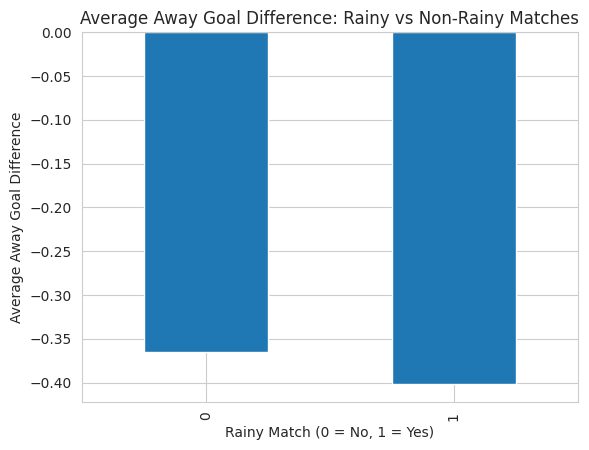

In [83]:
final_clean_df.groupby("rainy_match")["away_goal_difference"].mean().plot(kind="bar")
plt.title("Average Away Goal Difference: Rainy vs Non-Rainy Matches")
plt.xlabel("Rainy Match (0 = No, 1 = Yes)")
plt.ylabel("Average Away Goal Difference")
plt.show()

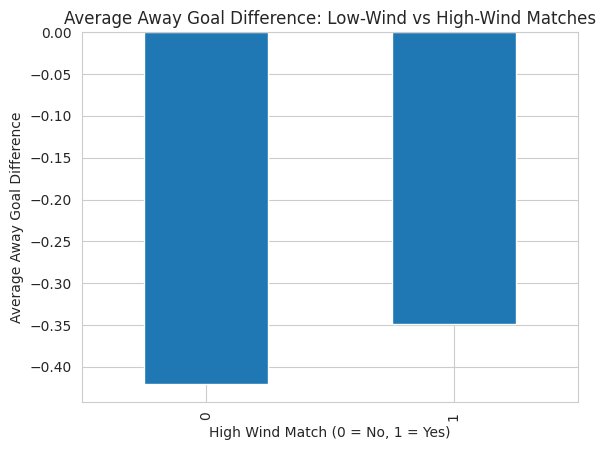

In [84]:
final_clean_df.groupby("high_wind_match")["away_goal_difference"].mean().plot(kind="bar")
plt.title("Average Away Goal Difference: Low-Wind vs High-Wind Matches")
plt.xlabel("High Wind Match (0 = No, 1 = Yes)")
plt.ylabel("Average Away Goal Difference")
plt.show()

The hypothesis tests in this section provide the main empirical results of the project. By examining temperature, precipitation, and wind conditions together with away-team goal difference, I can evaluate whether weather-related environmental conditions are associated with away performances in UEFA Champions League matches.

The hypothesis-testing results suggest that the weather variables considered in this project do not show a statistically significant association with away-team goal difference in UEFA Champions League matches. Neither mean temperature, precipitation, nor wind speed produced significant effects at conventional significance levels. Although small differences appear in the group averages, these differences are not strong enough to support the claim that weather conditions systematically affect away performance in this dataset.

## Part 14: Estimating Travel Distance for Away Teams

To approximate the travel burden of away teams, I estimate the geodesic distance between the away club’s home location and the match location. I identify each club’s representative home stadium based on the most frequently observed home stadium in the dataset, and then use the stadium coordinates to compute travel distance in kilometers.

In [85]:
club_home_stadium_df = (
    clean_df.groupby("home_club_name")["stadium"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
)

club_home_stadium_df.columns = ["club_name", "home_stadium"]

print("Representative home stadium table created successfully!")
club_home_stadium_df.head()

Representative home stadium table created successfully!


,club_name,home_stadium
0,1. Fußballclub Union Berlin,Olympiastadion Berlin
1,"AC Sparta Praha, a. s.",epet Arena
2,AFC Ajax Amsterdam,Johan Cruijff ArenA
3,AO FK Zenit Sankt-Peterburg,Petrovsky
4,APOEL Nicosia,GSP Stadium


In [86]:
club_home_location_df = club_home_stadium_df.merge(
    stadium_reference_filled,
    left_on="home_stadium",
    right_on="stadium_name",
    how="left"
)

club_home_location_df = club_home_location_df.rename(columns={
    "city": "home_city",
    "country": "home_country",
    "latitude": "home_latitude",
    "longitude": "home_longitude"
})

print("Club home-location table created successfully!")
club_home_location_df.head()

Club home-location table created successfully!


,club_name,home_stadium,stadium_name,home_city,home_country,home_latitude,home_longitude
0,1. Fußballclub Union Berlin,Olympiastadion Berlin,Olympiastadion Berlin,Berlin,Germany,52.5147,13.2395
1,"AC Sparta Praha, a. s.",epet Arena,epet Arena,Prague,Czech Republic,50.0760,14.4330
2,AFC Ajax Amsterdam,Johan Cruijff ArenA,Johan Cruijff ArenA,Amsterdam,Netherlands,52.3143,4.9411
3,AO FK Zenit Sankt-Peterburg,Petrovsky,Petrovsky,Saint Petersburg,Russia,59.9560,30.2490
4,APOEL Nicosia,GSP Stadium,GSP Stadium,Nicosia,Cyprus,35.1649,33.3649


In [87]:
distance_df = final_clean_df.merge(
    club_home_location_df[[
        "club_name",
        "home_stadium",
        "home_city",
        "home_country",
        "home_latitude",
        "home_longitude"
    ]],
    left_on="away_club_name",
    right_on="club_name",
    how="left"
)

print("Away-team home locations merged successfully!")
print("Shape of distance dataset:", distance_df.shape)
distance_df.head()

Away-team home locations merged successfully!
Shape of distance dataset: (1850, 26)


,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance,away_win,away_not_lose,away_goal_difference,...,precipitation_sum,windspeed_10m_max,rainy_match,high_wind_match,club_name,home_stadium,home_city,home_country,home_latitude,home_longitude
0,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0,1,1,2,...,0.1,6.8,1,0,Futebol Clube do Porto,Estádio do Dragão,Porto,Portugal,41.1614,-8.5835
1,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0,0,0,-3,...,0.0,16.2,0,0,Futbolniy Klub Dynamo Kyiv,NSK Olimpisky,Kyiv,Ukraine,50.4338,30.5218
2,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0,1,1,1,...,0.3,15.9,1,0,Arsenal Football Club,Emirates Stadium,London,England,51.5549,-0.1084
3,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0,1,1,1,...,0.0,9.7,0,0,FC Schalke 04,Veltins-Arena,Gelsenkirchen,Germany,51.5542,7.0678
4,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0,0,0,-3,...,0.0,6.5,0,0,AO FK Zenit Sankt-Peterburg,Petrovsky,Saint Petersburg,Russia,59.9560,30.2490


In [88]:
print("Missing away home latitude values:", distance_df["home_latitude"].isnull().sum())
print("Missing away home longitude values:", distance_df["home_longitude"].isnull().sum())

Missing away home latitude values: 0
Missing away home longitude values: 0


In [89]:
from geopy.distance import geodesic

def calculate_distance(row):
    try:
        home_coords = (row["home_latitude"], row["home_longitude"])
        match_coords = (row["latitude"], row["longitude"])
        return geodesic(home_coords, match_coords).kilometers
    except Exception:
        return np.nan

distance_df["travel_distance_km"] = distance_df.apply(calculate_distance, axis=1)

print("Travel distances calculated successfully!")
distance_df[[
    "away_club_name",
    "home_stadium",
    "stadium",
    "travel_distance_km"
]].head()

Travel distances calculated successfully!


,away_club_name,home_stadium,stadium,travel_distance_km
0,Futebol Clube do Porto,Estádio do Dragão,Maksimir,2046.686308
1,Futbolniy Klub Dynamo Kyiv,NSK Olimpisky,Parc des Princes,2037.194130
2,Arsenal Football Club,Emirates Stadium,Stade de la Mosson,929.843828
3,FC Schalke 04,Veltins-Arena,Stadio Georgios Karaiskakis,1995.039270
4,AO FK Zenit Sankt-Peterburg,Petrovsky,La Rosaleda,3569.223260


In [90]:
print(distance_df["travel_distance_km"].describe())

count    1850.000000
mean     1424.735083
std       875.841831
min         0.000000
25%       781.015030
50%      1305.556032
75%      1868.360812
max      6920.131925
Name: travel_distance_km, dtype: float64


At this stage, I have estimated the approximate travel distance of away teams by using representative home-stadium coordinates and match-location coordinates. This distance variable can now be used together with weather variables in the final statistical analysis.

## Part 15: Distance-Based Hypothesis Testing

In this section, I examine whether travel distance is associated with away-team performance in UEFA Champions League matches. Using the estimated geodesic travel distance, I test whether longer away trips are related to worse away goal differences. I also compare short-distance and long-distance matches to see whether travel burden leads to statistically meaningful differences in away performance.

In [91]:
corr_dist, p_dist = stats.pearsonr(
    distance_df["travel_distance_km"],
    distance_df["away_goal_difference"]
)

print("Travel Distance vs Away Goal Difference")
print("Correlation coefficient:", corr_dist)
print("P-value:", p_dist)

Travel Distance vs Away Goal Difference
Correlation coefficient: -0.014464602746704735
P-value: 0.534100932313645


As an initial statistical check, I first calculate the correlation between travel distance and away goal difference. This helps me evaluate whether there is a linear relationship between travel burden and away-team performance.

In [92]:
distance_threshold = distance_df["travel_distance_km"].median()
distance_df["long_distance_match"] = (distance_df["travel_distance_km"] > distance_threshold).astype(int)

print("Distance threshold:", distance_threshold)
print("\nLong-distance match distribution:")
print(distance_df["long_distance_match"].value_counts())

Distance threshold: 1305.556031631773

Long-distance match distribution:
long_distance_match
1    925
0    925
Name: count, dtype: int64


To make the comparison more interpretable, I divide the dataset into short-distance and long-distance matches using the median travel distance as the threshold. This creates two relatively balanced groups for statistical comparison.

In [93]:
long_distance_group = distance_df[distance_df["long_distance_match"] == 1]["away_goal_difference"]
short_distance_group = distance_df[distance_df["long_distance_match"] == 0]["away_goal_difference"]

t_stat_dist, p_value_dist = stats.ttest_ind(long_distance_group, short_distance_group, equal_var=False)

print("Long-Distance vs Short-Distance Matches")
print("T-statistic:", t_stat_dist)
print("P-value:", p_value_dist)

Long-Distance vs Short-Distance Matches
T-statistic: -0.34223376664494165
P-value: 0.7322139155052547


In [94]:
print("Average away goal difference in long-distance matches:", long_distance_group.mean())
print("Average away goal difference in short-distance matches:", short_distance_group.mean())

Average away goal difference in long-distance matches: -0.40216216216216216
Average away goal difference in short-distance matches: -0.3675675675675676


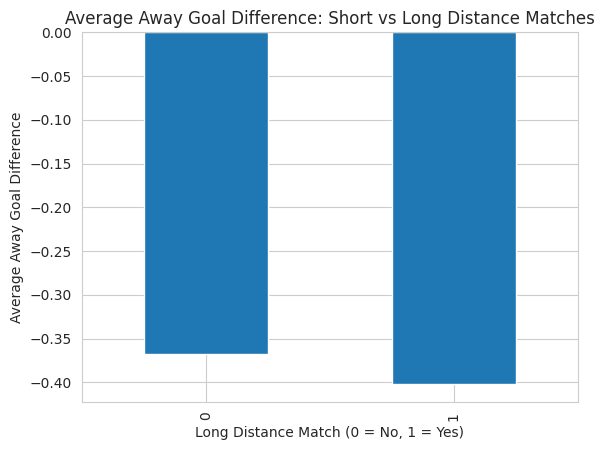

In [95]:
distance_df.groupby("long_distance_match")["away_goal_difference"].mean().plot(kind="bar")
plt.title("Average Away Goal Difference: Short vs Long Distance Matches")
plt.xlabel("Long Distance Match (0 = No, 1 = Yes)")
plt.ylabel("Average Away Goal Difference")
plt.show()

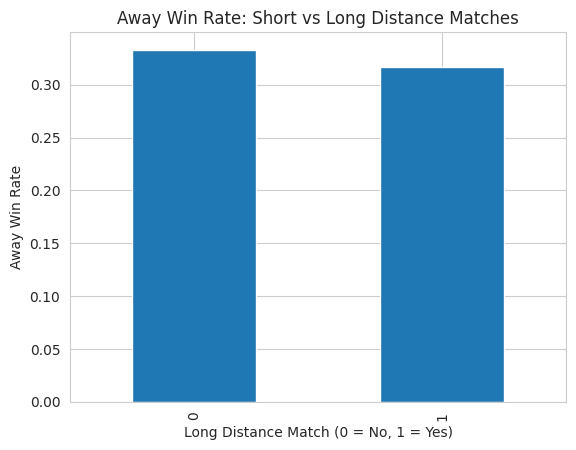

In [96]:
distance_df.groupby("long_distance_match")["away_win"].mean().plot(kind="bar")
plt.title("Away Win Rate: Short vs Long Distance Matches")
plt.xlabel("Long Distance Match (0 = No, 1 = Yes)")
plt.ylabel("Away Win Rate")
plt.show()

The distance-based hypothesis tests help evaluate whether travel burden is associated with away-team performance. By combining a continuous correlation analysis with a grouped comparison of short- and long-distance matches, I can assess whether longer travel is linked to worse outcomes for away teams.

The distance-based hypothesis tests suggest that estimated travel distance is not significantly associated with away-team performance in this dataset. Although long-distance matches show slightly worse average away goal differences and slightly lower away win rates, these differences are not statistically significant at conventional significance levels.

### Final Remark

In conclusion, this project found no statistically significant evidence that weather conditions or estimated travel distance alone have a strong effect on away-team performance in UEFA Champions League matches. Nevertheless, the enrichment process and statistical analysis provide a useful framework for studying how external contextual factors may interact with football performance.

#AI Appendix

This project was completed with limited AI assistance. AI was used mainly for structuring the notebook sections, improving the wording of explanations, debugging parts of the Python code, and refining the presentation of the statistical analysis.

The core project decisions, including the research topic, dataset choice, enrichment strategy, variable selection, interpretation of results, and final conclusions, were reviewed and decided by the student. All code used in the final notebook was checked, adapted, and run by the student.

AI was not used as a replacement for the analysis itself, but as a supporting tool during the organization, debugging, and writing process.

Because of the fact that geopy caused error in students dataset student had to collect coordinates with the help of the AI.